In [1]:
from pathlib import Path
from collections import Counter
import json

import matplotlib.pyplot as plt
import pandas as pd


# 01 - Explore the Dataset

This notebook profiles one Train Ticket failure scenario before implementation of the production data loader and anomaly detectors. It inspects file coverage, normalizes the three telemetry formats, and verifies whether their timestamps can support cross-source correlation.

> **Scope:** the notebook performs exploratory aggregation and visualization. Any apparent spike is descriptive evidence only; formal anomaly labels belong in the detector notebooks.

## 1. Scenario Metadata

Select one scenario folder and parse its identifier into the changed microservice, third-party library, version, and collection date.

**Technical notes**

- The identifier is split from right to left because service names contain hyphens.
- The selected folder is treated as an experiment context; its monitoring files may still contain telemetry from many cluster services.
- Presence flags validate dataset completeness but do not imply that a source contains an anomaly.

In [2]:

DATA_ROOT = Path("../data/raw")
SCENARIO_ID = "ts-auth-mongo_4.4.15_2022-07-13"
scenario = DATA_ROOT / SCENARIO_ID

# Tách từ phải sang trái
service_library, version, date = SCENARIO_ID.rsplit("_", 2)
service, library = service_library.rsplit("-", 1)

find = lambda *patterns: [
    p for pattern in patterns for p in scenario.glob(pattern)
]

raw_logs = find("LOGS_*.txt")
structured_logs = find("LOGS_*_structured.csv")
log_templates = find("LOGS_*_templates.csv")
metrics = find("Monitoring_*")
traces = find("Trace_*", "Traces_*")
descriptions = find("*description*", "*Description*", "*anomal*", "*Anomal*")

metadata = pd.DataFrame([{
    "scenario_id": SCENARIO_ID,
    "changed_microservice": service,
    "library": library,
    "version": version,
    "date": date.replace("-", ""),
    "has_logs": bool(raw_logs and structured_logs and log_templates),
    "has_metrics": bool(metrics),
    "has_traces": bool(traces),
}])

display(metadata)
print("Anomaly descriptions:", [p.name for p in descriptions])

,scenario_id,changed_microservice,library,version,date,has_logs,has_metrics,has_traces
0,ts-auth-mongo_4.4.15_2022-07-13,ts-auth,mongo,4.4.15,20220713,True,True,True


Anomaly descriptions: ['potentialAnomalies_ts-auth-service_mongodb-4.4.15.txt', 'potentialAnomalies_ts-auth-service_mongodb-4.4.15.txt']


## 2. File Inventory

List every artifact in the selected scenario and summarize the available log, metric, and trace formats. This inventory defines the inputs that a future `data_loader.py` must support.

**Technical notes**

- Structured logs and templates are preferred over reparsing the raw text file.
- Prometheus metrics and Jaeger traces are stored as nested JSON rather than tabular CSV.
- Recursive discovery is required because monitoring and trace files live inside source-specific subdirectories.

In [3]:

all_files = [p for p in scenario.rglob("*") if p.is_file()]

raw_logs = list(scenario.glob("LOGS_*.txt"))
structured_logs = list(scenario.glob("LOGS_*_structured.csv"))
log_templates = list(scenario.glob("LOGS_*_templates.csv"))

metric_files = [
    p for folder in scenario.glob("Monitoring_*")
    for p in folder.rglob("*") if p.is_file()
]

trace_files = [
    p for folder in scenario.glob("Trace*")
    for p in folder.rglob("*") if p.is_file()
]

print("Selected scenario contains:")
print(f"- {len(raw_logs)} raw log file(s)")
print(f"- {len(structured_logs)} structured log CSV(s)")
print(f"- {len(log_templates)} log template CSV(s)")
print(f"- {len(metric_files)} monitoring/KPI file(s)")
print(f"- {len(trace_files)} trace file(s)")

print("\nMetric formats:", dict(Counter(p.suffix.lower() for p in metric_files)))
print("Trace formats:", dict(Counter(p.suffix.lower() for p in trace_files)))

print("\nAvailable metrics:")
for p in metric_files:
    print("-", p.stem)

print("\nAll files:")
for p in all_files:
    print("-", p.relative_to(scenario))

Selected scenario contains:
- 1 raw log file(s)
- 1 structured log CSV(s)
- 1 log template CSV(s)
- 7 monitoring/KPI file(s)
- 40 trace file(s)

Metric formats: {'.json': 7}
Trace formats: {'.json': 40}

Available metrics:
- ts-auth-service_3_Mongo_4.4.15.json_container_cpu_usage_seconds_total
- ts-auth-service_3_Mongo_4.4.15.json_container_memory_working_set_bytes
- ts-auth-service_3_Mongo_4.4.15.json_container_network_transmit_packets_total
- ts-auth-service_3_Mongo_4.4.15.json_node_cpu_seconds_total
- ts-auth-service_3_Mongo_4.4.15.json_node_memory_MemAvailable_bytes
- ts-auth-service_3_Mongo_4.4.15.json_node_memory_MemTotal_bytes
- ts-auth-service_3_Mongo_4.4.15.json_node_network_transmit_packets_total

All files:
- LOGS_ts-auth-service_3_Mongo_4.4.15.txt
- LOGS_ts-auth-service_3_Mongo_4.4.15.txt_structured.csv
- LOGS_ts-auth-service_3_Mongo_4.4.15.txt_templates.csv
- potentialAnomalies_ts-auth-service_mongodb-4.4.15.txt
- Monitoring_ts-auth-service_3_Mongo_4.4.15.json_2022-07-13\t

## 3. Explore Metrics

Flatten Prometheus Matrix JSON into one row per timestamp and label set, then build an inventory by metric name and service label.

**Technical notes**

- One JSON file usually represents one metric name, while `data.result` may contain **many time series** distinguished by labels such as pod, container, and instance.
- `series_count` counts distinct label sets; `count` counts all sampled points across those series.
- The observed sampling interval is estimated from consecutive timestamps. A series with fewer than two samples has no measurable interval.
- A missing pod or container label does not mean that the metric value is missing; node-level series often do not carry workload labels.

In [4]:

metric_files = [
    p for folder in scenario.glob("Monitoring_*")
    for p in folder.rglob("*.json")
]

rows = []


def get_frequency_seconds(timestamps):
    differences = (
        timestamps.sort_values()
        .diff()
        .dt.total_seconds()
        .dropna()
    )

    return differences.median() if not differences.empty else None # tránh lỗi khi chỉ có 1 timestamp

for file in metric_files:
    data = json.loads(file.read_text(encoding="utf-8"))

    for series_id, series in enumerate(data["data"]["result"]):
        labels = series.get("metric", {})
        metric_name = labels.get("__name__", file.stem)

        for timestamp, value in series.get("values", []):
            rows.append({
                "metric_name": metric_name,
                "series_id": f"{file.name}:{series_id}",
                "timestamp": pd.to_datetime(timestamp, unit="s"),
                "value": pd.to_numeric(value, errors="coerce"),
                "service": labels.get("service"),
                "instance": labels.get("instance"),
                "pod": labels.get("pod"),
                "container": labels.get("container"),
            })

metrics = pd.DataFrame(rows).sort_values("timestamp")

# Thống kê từng Prometheus time series
series_stats = (
    metrics.groupby(
        ["metric_name", "service", "series_id"],
        dropna=False
    )
    .agg(
        count=("value", "count"),
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        missing_values=("value", lambda x: x.isna().mean()),
        frequency_seconds=("timestamp", get_frequency_seconds),
    )
    .reset_index()
)

# Inventory tổng hợp
metric_inventory = (
    series_stats.groupby(["metric_name", "service"], dropna=False)
    .agg(
        series_count=("series_id", "nunique"),
        count=("count", "sum"),
        start_time=("start_time", "min"),
        end_time=("end_time", "max"),
        frequency_seconds=("frequency_seconds", "median"),
        missing_rate=("missing_values", "mean"),
    )
    .reset_index()
    .sort_values("metric_name")
)

display(metric_inventory)
display(metrics.head())

,metric_name,service,series_count,count,start_time,end_time,frequency_seconds,missing_rate
0,container_cpu_usage_seconds_total,kubelet,2438,263925,2022-07-13 10:52:47.016000032,2022-07-13 11:52:44.369999886,30.0,0.0
1,container_memory_working_set_bytes,kubelet,3433,367905,2022-07-13 10:53:05.180999994,2022-07-13 11:52:59.461999893,30.0,0.0
2,container_network_transmit_packets_total,kubelet,6422,645817,2022-07-13 10:52:57.721999884,2022-07-13 11:52:53.315999985,30.0,0.0
3,node_cpu_seconds_total,node-exporter,632,151680,2022-07-13 10:53:08.290999889,2022-07-13 11:53:05.686000109,15.0,0.0
4,node_memory_MemAvailable_bytes,node-exporter,10,2400,2022-07-13 10:53:08.273999929,2022-07-13 11:53:07.407000065,15.0,0.0
5,node_memory_MemTotal_bytes,node-exporter,10,2400,2022-07-13 10:53:10.381000042,2022-07-13 11:53:08.592000008,15.0,0.0
6,node_network_transmit_packets_total,node-exporter,70,16800,2022-07-13 10:53:07.395999908,2022-07-13 11:53:02.319000006,15.0,0.0


,metric_name,series_id,timestamp,value,service,instance,pod,container
239565,container_cpu_usage_seconds_total,ts-auth-service_3_Mongo_4.4.15.json_container_...,2022-07-13 10:52:47.016000032,0.526814,kubelet,10.252.1.21:10250,None,None
68790,container_cpu_usage_seconds_total,ts-auth-service_3_Mongo_4.4.15.json_container_...,2022-07-13 10:52:47.016000032,6597.571652,kubelet,10.252.1.21:10250,ovnkube-node-2jn7j,ovnkube-node
98789,container_cpu_usage_seconds_total,ts-auth-service_3_Mongo_4.4.15.json_container_...,2022-07-13 10:52:47.016000032,8500.290394,kubelet,10.252.1.21:10250,eventbus-default-stan-0,None
54150,container_cpu_usage_seconds_total,ts-auth-service_3_Mongo_4.4.15.json_container_...,2022-07-13 10:52:47.016000032,203.550242,kubelet,10.252.1.21:10250,eventbus-default-stan-0,metrics
148770,container_cpu_usage_seconds_total,ts-auth-service_3_Mongo_4.4.15.json_container_...,2022-07-13 10:52:47.016000032,0.077988,kubelet,10.252.1.21:10250,None,None


### 3.1 Metric Timeline

Filter series associated with the changed service and visualize CPU, memory, and network behavior over time.

**Technical notes**

- Prometheus metrics ending in `_total` are counters. Their first difference is divided by elapsed seconds to obtain a per-second rate.
- Counter resets produce negative differences, which are clipped to zero for this exploratory plot.
- Each series is resampled independently to a one-minute grid before aggregation. This prevents timestamp offsets between pods from creating artificial saw-tooth patterns.
- The per-series mean summarizes samples within a minute; the cross-series sum represents total service consumption. Native 15/30-second data should still be retained by the detector.

Target service: ts-auth
Selected metrics: ['container_memory_working_set_bytes', 'container_cpu_usage_seconds_total', 'container_network_transmit_packets_total']


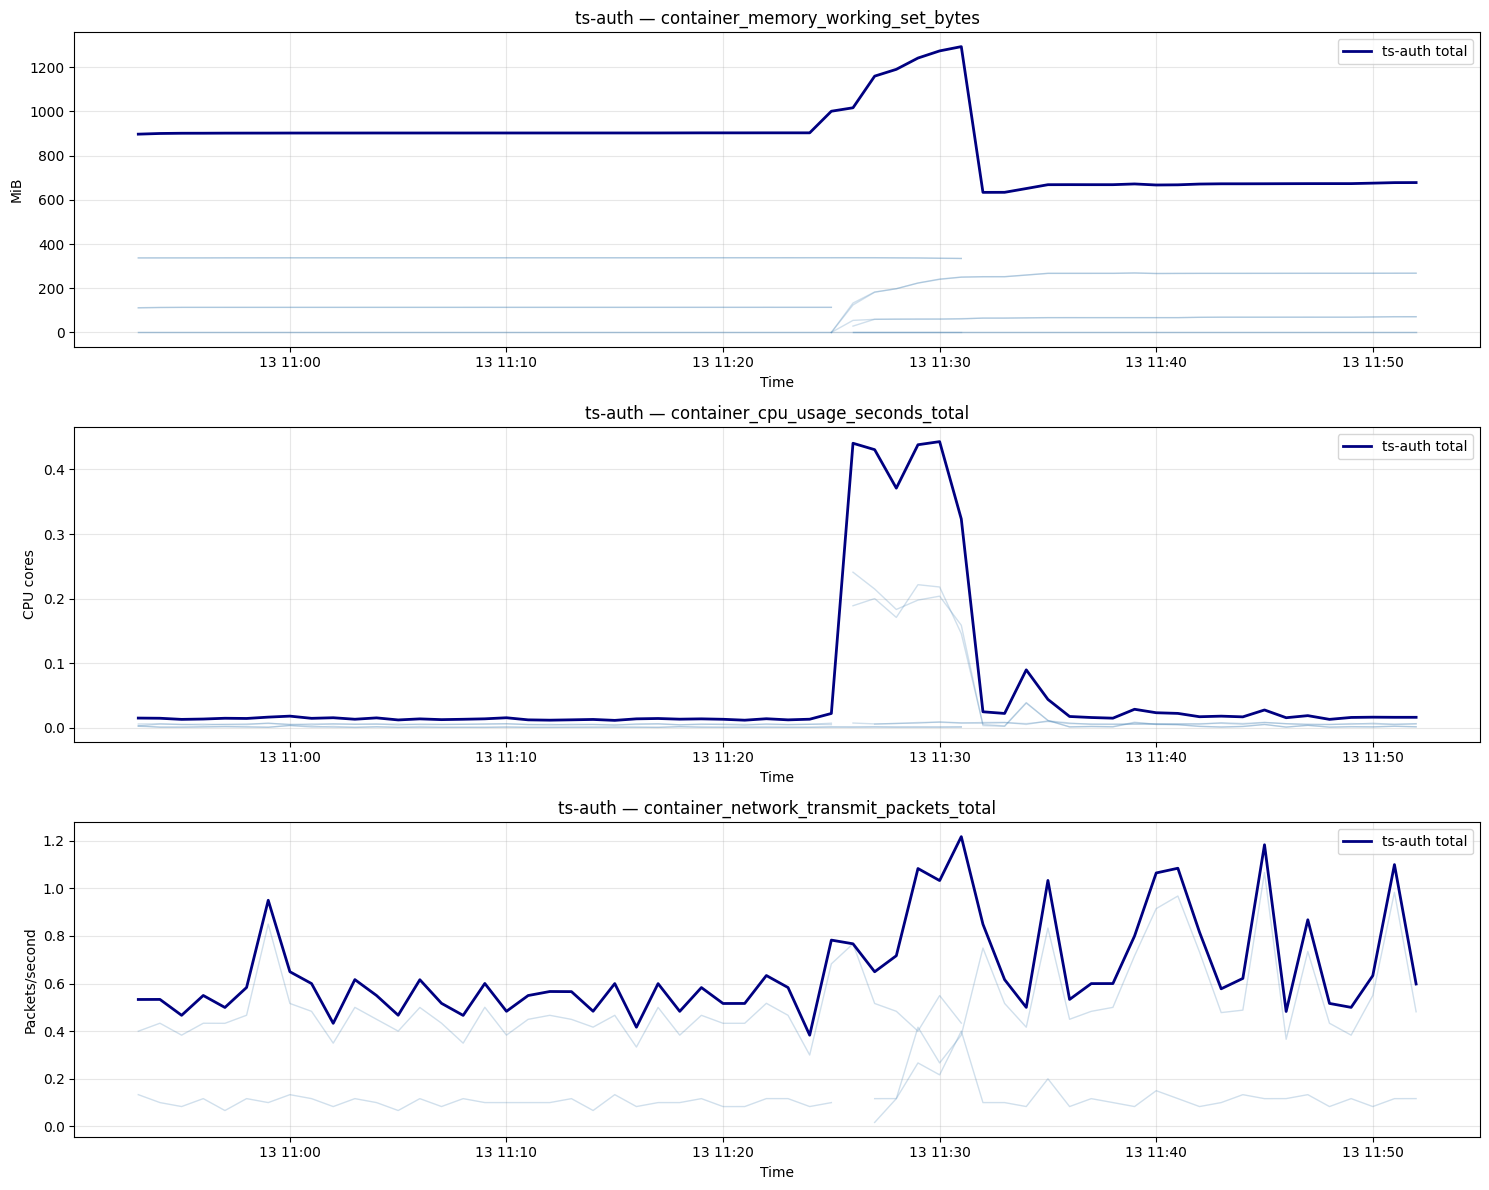

In [5]:

target_service = service
window = "1min"

# Lọc các series thuộc target service
service_metrics = metrics[
    metrics["pod"].str.contains(target_service, case=False, na=False, regex=False) |
    metrics["container"].str.contains(target_service, case=False, na=False, regex=False)
].copy()

# keywords dựa vào tên các file json trong metrics
keywords = ["cpu", "memory", "network"]
selected_metrics = [
    name for name in service_metrics["metric_name"].dropna().unique()
    if any(keyword in name.lower() for keyword in keywords)
]

if not selected_metrics:
    raise ValueError(f"Không tìm thấy metric cho service: {target_service}")

print("Target service:", target_service)
print("Selected metrics:", selected_metrics)

fig, axes = plt.subplots(
    len(selected_metrics),
    1,
    figsize=(15, 4 * len(selected_metrics)),
    squeeze=False
)

for ax, metric_name in zip(axes[:, 0], selected_metrics):
    df = (
        service_metrics[service_metrics["metric_name"] == metric_name]
        .sort_values(["series_id", "timestamp"])
        .copy()
    )

    # Counter: chuyển giá trị tích lũy thành rate/second cho từng series
    if metric_name.endswith("_total"):
        time_diff = (
            df.groupby("series_id")["timestamp"]
            .diff()
            .dt.total_seconds()
        )
        value_diff = df.groupby("series_id")["value"].diff()

        df["plot_value"] = (value_diff / time_diff).clip(lower=0)

        ylabel = (
            "CPU cores"
            if "cpu" in metric_name.lower()
            else "Packets/second"
        )
    else:
        df["plot_value"] = df["value"]

        # Đổi bytes thành MiB để dễ đọc
        if "bytes" in metric_name.lower():
            df["plot_value"] /= 1024**2
            ylabel = "MiB"
        else:
            ylabel = "Value"

    # Đưa từng series về cùng mốc thời gian
    per_series = (
        df.set_index("timestamp")
        .groupby("series_id")["plot_value"]
        .resample(window)
        .mean()
        .reset_index()
    )

    # Vẽ riêng từng series bằng đường mờ để kiểm tra artifact
    for _, group in per_series.groupby("series_id"):
        ax.plot(
            group["timestamp"],
            group["plot_value"],
            color="steelblue",
            alpha=0.25,
            linewidth=1
        )

    # Tổng hợp toàn service sau khi các series đã cùng timestamp
    service_total = (
        per_series.groupby("timestamp")["plot_value"]
        .sum(min_count=1)
    )

    ax.plot(
        service_total.index,
        service_total.values,
        color="navy",
        linewidth=2,
        label=f"{target_service} total"
    )

    ax.set_title(f"{target_service} — {metric_name}")
    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Explore Logs

Read the pre-parsed structured log and template tables, construct a timestamp, inspect the schema, and rank frequently occurring templates.

**Technical notes**

- `Date` and `Time` are combined into a single timestamp with invalid values coerced to missing.
- The file has no explicit service column, so the changed service is supplied from scenario metadata.
- `EventId` and `EventTemplate` are stable structured signals and are preferable to immediate TF-IDF or clustering during the PoC.
- The dominant level is descriptive only; the same template may appear with more than one severity.

In [6]:

structured_file = next(scenario.glob("LOGS_*_structured.csv"))
template_file = next(scenario.glob("LOGS_*_templates.csv"))

logs = pd.read_csv(structured_file)
templates = pd.read_csv(template_file)


logs["Level"] = logs["Level"].astype(str).str.strip().str.upper()
top_templates = (
    logs.groupby(["EventId", "EventTemplate"], dropna=False)
        .agg(
            count=("LineId", "count"),
            level=("Level", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
            level_distribution=("Level", lambda x: x.value_counts().to_dict()),
        )
        .reset_index()
        .rename(columns={
            "EventId": "template_id",
            "EventTemplate": "example_template"
        })
        .sort_values("count", ascending=False)
        .head(20)
        .reset_index(drop=True)
)

# Tạo timestamp chuẩn và bổ sung service từ metadata Step 1
logs["Timestamp"] = pd.to_datetime(
    logs["Date"].astype(str) + " " + logs["Time"].astype(str),
    errors="coerce"
)
logs["Service"] = service

schema = pd.DataFrame([
    ["LineId", "ID của dòng log", "Có"],
    ["Date + Time", "Timestamp; nên gộp thành Timestamp", "Có"],
    ["Level", "Mức độ log: INFO/WARN/ERROR...", "Có"],
    ["LoggingReporter", "Thread/logger/component phát sinh log", "Có"],
    ["Content", "Nội dung log gốc", "Có"],
    ["EventId", "ID của log template", "Có"],
    ["EventTemplate", "Mẫu log đã parse", "Có"],
    ["ParameterList", "Các biến được trích từ Content", "Tùy chọn"],
    ["Number", "Trường phụ của parser, cần kiểm tra ý nghĩa", "Không ưu tiên"],
    ["Service", "Không có sẵn; lấy từ scenario metadata", "Có"],
], columns=["column", "meaning", "usable_for_pipeline"])

display(logs.head())
display(top_templates)
display(schema)

print("Structured log shape:", logs.shape)
print("Template shape:", templates.shape)
print("Time range:", logs["Timestamp"].min(), "→", logs["Timestamp"].max())
print("Log levels:", logs["Level"].value_counts(dropna=False).to_dict())
print("Unique EventId:", logs["EventId"].nunique())
print("Missing values:")
display(logs.isna().sum().to_frame("missing_count"))

,LineId,Date,Time,Level,Number,LoggingReporter,Content,EventId,EventTemplate,ParameterList,Timestamp,Service
0,1,2022-07-13,19:51:19.068,INFO,1,[io-12340-exec-8] i.j.internal.reporters.Logg...,Span reported: 8495060c42b1b1f8:8495060c42b1b1...,46c6d92e,Span reported: <*> - <*>,"['8495060c42b1b1f8:8495060c42b1b1f8:0:1', 'get...",2022-07-13 19:51:19.068,ts-auth
1,2,2022-07-13,19:51:19.061,INFO,1,[o-15678-exec-10] i.j.internal.reporters.Logg...,Span reported: 8495060c42b1b1f8:33ab0e3eba71ca...,46c6d92e,Span reported: <*> - <*>,['8495060c42b1b1f8:33ab0e3eba71cac4:153789fdc0...,2022-07-13 19:51:19.061,ts-auth
2,3,2022-07-13,19:51:19.061,INFO,1,[io-12340-exec-8] i.j.internal.reporters.Logg...,Span reported: 8495060c42b1b1f8:153789fdc037ca...,46c6d92e,Span reported: <*> - <*>,['8495060c42b1b1f8:153789fdc037cacc:8495060c42...,2022-07-13 19:51:19.061,ts-auth
3,4,2022-07-13,19:51:19.058,INFO,1,[o-15678-exec-10] v.controller.VerifyCodeCont...,receivedCode LOQ7,5d2e6775,receivedCode <*>,['LOQ7'],2022-07-13 19:51:19.058,ts-auth
4,5,2022-07-13,19:51:19.059,INFO,1,[o-15678-exec-10] v.service.impl.VerifyCodeSe...,GET Code By cookieId 70CAC57DCCCB4F4C9FC1BC62A...,81cfb868,GET Code By cookieId <*> is <*>,"['70CAC57DCCCB4F4C9FC1BC62AC8CCD9B', ':null']",2022-07-13 19:51:19.059,ts-auth


,template_id,example_template,count,level,level_distribution
0,46c6d92e,Span reported: <*> - <*>,25695,INFO,{'INFO': 25695}
1,6a60802a,Generating unique operation named: <*>,18699,INFO,{'INFO': 18699}
2,6e3a69ad,"Mapped <*> || <*> || application/json]}"" onto ...",9864,INFO,{'INFO': 9864}
3,49b33cd1,Mapping filter: <*> to: [/*],6680,INFO,{'INFO': 6680}
4,c3bcf5f7,Mapped <*> onto public <*> <*>,6278,INFO,{'INFO': 6278}
5,4eac5fb4,Bean <*> of type <*> is not eligible for getti...,5916,INFO,{'INFO': 5916}
6,c5daac56,Mapped <*> || <*> onto public <*> <*>,3213,INFO,{'INFO': 3213}
7,e6f1d0c1,No bean named <*> has been explicitly defined....,2535,INFO,{'INFO': 2535}
8,c2a4e265,Mapped URL path <*> onto handler of type [clas...,2466,INFO,{'INFO': 2466}
9,470d576f,Tomcat <*> <*> port(s): <*> (http),1666,INFO,{'INFO': 1666}


,column,meaning,usable_for_pipeline
0,LineId,ID của dòng log,Có
1,Date + Time,Timestamp; nên gộp thành Timestamp,Có
2,Level,Mức độ log: INFO/WARN/ERROR...,Có
3,LoggingReporter,Thread/logger/component phát sinh log,Có
4,Content,Nội dung log gốc,Có
5,EventId,ID của log template,Có
6,EventTemplate,Mẫu log đã parse,Có
7,ParameterList,Các biến được trích từ Content,Tùy chọn
8,Number,"Trường phụ của parser, cần kiểm tra ý nghĩa",Không ưu tiên
9,Service,Không có sẵn; lấy từ scenario metadata,Có


Structured log shape: (147205, 12)
Template shape: (1182, 3)
Time range: 2022-06-14 17:26:35.024000 → 2022-07-13 19:51:19.068000
Log levels: {'INFO': 146599, 'ERROR': 458, 'WARN': 148}
Unique EventId: 1182
Missing values:


,missing_count
LineId,0
Date,0
Time,0
Level,0
Number,0
LoggingReporter,0
Content,0
EventId,0
EventTemplate,0
ParameterList,0


### 4.1 WARN/ERROR Timeline

Aggregate WARN and ERROR records into one-minute windows and inspect which templates dominate high-volume windows.

**Technical notes**

- Severity values are stripped and upper-cased before filtering.
- The 99th percentile is a lightweight exploratory threshold, not a production anomaly rule.
- A window with no WARN or ERROR may still be abnormal through INFO-template volume, metrics, or trace latency.

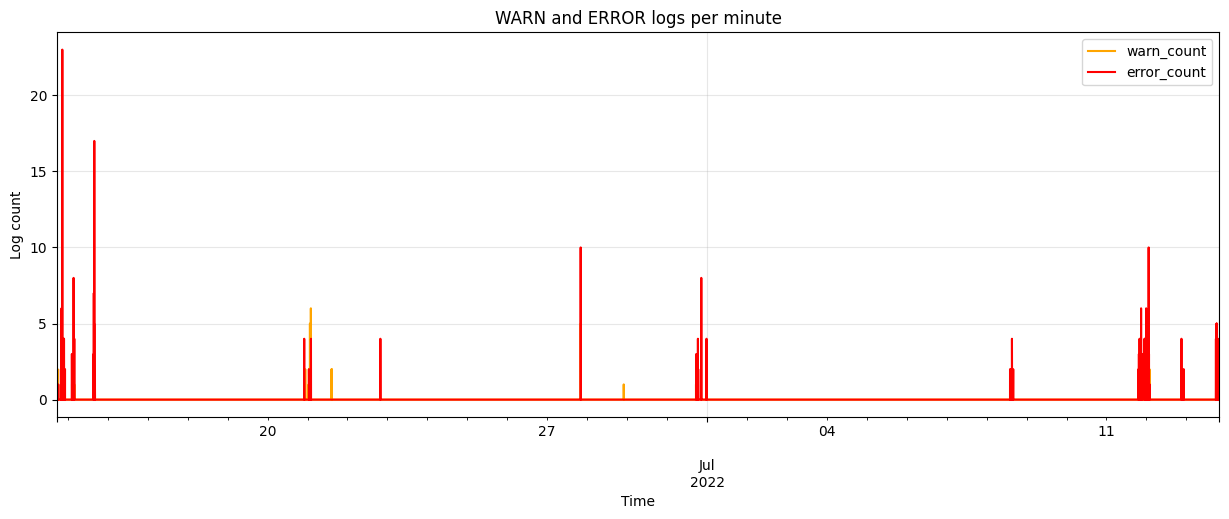

Các phút có WARN/ERROR spike:


,warn_count,error_count
Timestamp,,
2022-06-14 20:41:00,0,23
2022-06-15 15:54:00,1,17
2022-06-27 20:06:00,5,10
2022-07-12 01:20:00,0,10
2022-06-15 15:55:00,0,9
2022-06-15 03:27:00,2,8
2022-06-30 20:34:00,0,8
2022-06-14 20:42:00,0,7
2022-06-15 15:36:00,0,7


Các WARN/ERROR template xuất hiện nhiều nhất trong một phút:


,Minute,EventId,Level,count,template,example_content
309,2022-07-12 01:20:00,dd845522,ERROR,10,"Left ticket info is empty, seat from date: <*>...","Left ticket info is empty, seat from date: Tue..."
129,2022-06-15 15:54:00,f2177c01,ERROR,8,Token expired: {} io.jsonwebtoken.ExpiredJwtEx...,Token expired: {} io.jsonwebtoken.ExpiredJwtEx...
127,2022-06-15 15:54:00,23edadba,ERROR,8,Servlet.service() for servlet [dispatcherServl...,Servlet.service() for servlet [dispatcherServl...
295,2022-07-11 23:50:00,dd845522,ERROR,6,"Left ticket info is empty, seat from date: <*>...","Left ticket info is empty, seat from date: Mon..."
255,2022-07-11 20:47:00,dd845522,ERROR,6,"Left ticket info is empty, seat from date: <*>...","Left ticket info is empty, seat from date: Mon..."
187,2022-06-27 20:06:00,154e4ace,ERROR,5,Error starting Tomcat context. Exception: org....,Error starting Tomcat context. Exception: org....
44,2022-06-14 20:41:00,be77bd1d,ERROR,5,"Delete trip error.Trip not found,TripId: <*>","Delete trip error.Trip not found,TripId: nullt..."
43,2022-06-14 20:41:00,b80b9fe6,ERROR,5,"Admin delete travel failed, trip id: <*>","Admin delete travel failed, trip id: nulltring"
347,2022-07-13 18:09:00,dd845522,ERROR,5,"Left ticket info is empty, seat from date: <*>...","Left ticket info is empty, seat from date: Sat..."
189,2022-06-27 20:06:00,7eeafb22,WARN,5,Exception encountered during context initializ...,Exception encountered during context initializ...


In [7]:

# Chỉ lấy WARN và ERROR
alert_logs = logs[
    logs["Level"].astype(str).str.strip().str.upper().isin(["WARN", "ERROR"])
].copy()

alert_logs["Level"] = alert_logs["Level"].str.strip().str.upper()
alert_logs = alert_logs.dropna(subset=["Timestamp"]).sort_values("Timestamp")

# Đếm WARN và ERROR theo phút
volume = (
    alert_logs.set_index("Timestamp")
        .resample("1min")
        .agg(
            warn_count=("Level", lambda x: x.eq("WARN").sum()),
            error_count=("Level", lambda x: x.eq("ERROR").sum()),
        )
        .fillna(0)
)

# Vẽ timeline
volume.plot(
    figsize=(15, 5),
    color=["orange", "red"],
    title="WARN and ERROR logs per minute"
)
plt.xlabel("Time")
plt.ylabel("Log count")
plt.grid(alpha=0.3)
plt.show()

# Phát hiện phút có WARN/ERROR thuộc top 1%
warn_threshold = volume["warn_count"].quantile(0.99)
error_threshold = volume["error_count"].quantile(0.99)

spikes = volume[
    ((volume["warn_count"] >= warn_threshold) & (volume["warn_count"] > 0)) |
    ((volume["error_count"] >= error_threshold) & (volume["error_count"] > 0))
].sort_values(["error_count", "warn_count"], ascending=False)

print("Các phút có WARN/ERROR spike:")
display(spikes.head(20))

# Template WARN/ERROR xuất hiện nhiều nhất trong từng phút
template_volume = (
    alert_logs.assign(Minute=alert_logs["Timestamp"].dt.floor("min"))
        .groupby(["Minute", "EventId", "Level"], dropna=False)
        .agg(
            count=("LineId", "count"),
            template=("EventTemplate", "first"),
            example_content=("Content", "first"),
        )
        .reset_index()
        .sort_values("count", ascending=False)
)

print("Các WARN/ERROR template xuất hiện nhiều nhất trong một phút:")
display(template_volume.head(20))

## 5. Explore Traces

Flatten Jaeger trace JSON into a span table and aggregate operational signals by minute, service, and operation.

**Technical notes**

- Service names are resolved through `processID -> processes -> serviceName`.
- Jaeger start times and durations are stored in microseconds; duration is converted to milliseconds.
- Error status is derived from the `error` tag or an HTTP status code of 400 or greater. Jaeger warnings such as clock-skew notices are not necessarily application errors.
- Duplicate `(trace_id, span_id)` pairs are removed because the same distributed trace may be returned by multiple service query files.
- Parent span relationships are retained for future topology/RCA work but are not used by the current PoC.
- Slow spans use the service-operation p95 as an exploratory reference, not a finalized detector threshold.

In [8]:

trace_files = [
    p for folder in scenario.glob("Trace*")
    for p in folder.rglob("*.json")
]

rows = []

for file in trace_files:
    payload = json.loads(file.read_text(encoding="utf-8"))

    for trace in payload.get("data", []):
        processes = trace.get("processes", {})

        for span in trace.get("spans", []):
            tags = {
                tag["key"]: tag.get("value")
                for tag in span.get("tags", [])
            }

            # Lấy parent span từ CHILD_OF reference
            parent_span_id = next(
                (
                    ref.get("spanID")
                    for ref in span.get("references", [])
                    if ref.get("refType") == "CHILD_OF"
                ),
                None
            )

            status_code = pd.to_numeric(
                tags.get("http.status_code"),
                errors="coerce"
            )

            error_tag = str(
                tags.get("error", "")
            ).strip().lower() == "true"

            is_error = error_tag or (
                pd.notna(status_code) and status_code >= 400
            )

            warnings = span.get("warnings") or []
            process = processes.get(span.get("processID"), {})

            rows.append({
                "trace_id": span.get("traceID"),
                "span_id": span.get("spanID"),
                "parent_span_id": parent_span_id,
                "service": process.get("serviceName"),
                "operation": span.get("operationName"),
                "start_time": pd.to_datetime(
                    span.get("startTime"),
                    unit="us",
                    errors="coerce"
                ),
                "duration_ms": (
                    pd.to_numeric(
                        span.get("duration"),
                        errors="coerce"
                    ) / 1000
                ),
                "status_code": status_code,
                "error": is_error,
                "warning": "; ".join(map(str, warnings)) if warnings else None,
            })

# Cùng một trace có thể xuất hiện trong nhiều file Jaeger
spans = (
    pd.DataFrame(rows)
    .drop_duplicates(["trace_id", "span_id"])
    .dropna(subset=["start_time"])
)

# Schema thực tế sau khi flatten
trace_schema = pd.DataFrame([
    ["trace_id", "Request/trace identifier", "Yes"],
    ["span_id", "Span identifier", "Yes"],
    ["parent_span_id", "Dependency relation", "No"],
    ["service", "Service tạo span", "Yes"],
    ["operation", "Tên operation/span", "Yes"],
    ["start_time", "Thời điểm bắt đầu", "Yes"],
    ["duration_ms", "Thời gian xử lý (milliseconds)", "Yes"],
    ["status_code", "HTTP status code nếu có", "Yes"],
    ["error", "Error tag hoặc HTTP status >= 400", "Yes"],
    ["warning", "Cảnh báo kỹ thuật từ Jaeger", "For review"],
], columns=["field", "meaning", "used_in_poc"])

display(trace_schema)

# Ưu tiên xem các span có warning hoặc error
warning_or_error_spans = (
    spans[
        spans["error"] | spans["warning"].notna()
    ][[
        "start_time",
        "service",
        "operation",
        "duration_ms",
        "status_code",
        "error",
        "warning",
        "trace_id",
        "span_id",
    ]]
    .sort_values(
        ["error", "start_time"],
        ascending=[False, True]
    )
)

print("Total spans:", len(spans))
print("Error spans:", int(spans["error"].sum()))
print("Warning spans:", int(spans["warning"].notna().sum()))

display(warning_or_error_spans.head(20))

# Xác định slow span theo p95 của từng service/operation
spans["slow_threshold_ms"] = (
    spans.groupby(["service", "operation"])["duration_ms"]
    .transform(lambda x: x.quantile(0.95))
)

spans["is_slow"] = (
    spans["duration_ms"] > spans["slow_threshold_ms"]
)

# Aggregate thành signal theo cửa sổ một phút
trace_features = (
    spans.assign(
        time_window=spans["start_time"].dt.floor("1min")
    )
    .groupby(
        ["time_window", "service", "operation"],
        dropna=False
    )
    .agg(
        span_count=("span_id", "count"),
        error_span_count=("error", "sum"),
        warning_span_count=("warning", lambda x: x.notna().sum()),
        error_rate=("error", "mean"),
        duration_avg=("duration_ms", "mean"),
        duration_p95=("duration_ms", lambda x: x.quantile(0.95)),
        duration_p99=("duration_ms", lambda x: x.quantile(0.99)),
        slow_span_count=("is_slow", "sum"),
    )
    .reset_index()
    .sort_values(
        ["time_window", "error_rate", "duration_p95"],
        ascending=[True, False, False]
    )
)

display(trace_features.head(20))

,field,meaning,used_in_poc
0,trace_id,Request/trace identifier,Yes
1,span_id,Span identifier,Yes
2,parent_span_id,Dependency relation,No
3,service,Service tạo span,Yes
4,operation,Tên operation/span,Yes
5,start_time,Thời điểm bắt đầu,Yes
6,duration_ms,Thời gian xử lý (milliseconds),Yes
7,status_code,HTTP status code nếu có,Yes
8,error,Error tag hoặc HTTP status >= 400,Yes
9,warning,Cảnh báo kỹ thuật từ Jaeger,For review


Total spans: 378
Error spans: 2
Warning spans: 207


,start_time,service,operation,duration_ms,status_code,error,warning,trace_id,span_id
137,2022-07-13 11:35:00.800,ts-travel-service,queryInfo,94300.619,500.0,True,None,147e01a41865a515,147e01a41865a515
4,2022-07-13 11:50:57.034,ts-admin-order-service,GET,6.715,500.0,True,None,dc13c5788075d01a,dc13c5788075d01a
52,2022-07-13 11:35:09.549,ts-ticketinfo-service,queryForStationId,22706.363,200.0,False,clock skew adjustment disabled; not applying c...,147e01a41865a515,aa3219e037a65f47
49,2022-07-13 11:35:12.452,ts-ticketinfo-service,GET,18408.395,200.0,False,clock skew adjustment disabled; not applying c...,147e01a41865a515,b4c5e2d738a83830
45,2022-07-13 11:35:21.857,ts-station-service,queryForStationId,7300.579,200.0,False,clock skew adjustment disabled; not applying c...,147e01a41865a515,8d28d9453b2f0740
51,2022-07-13 11:35:32.352,ts-ticketinfo-service,queryForStationId,764.880,200.0,False,clock skew adjustment disabled; not applying c...,147e01a41865a515,e0b5539c09a397c8
53,2022-07-13 11:35:32.551,ts-ticketinfo-service,GET,513.272,200.0,False,clock skew adjustment disabled; not applying c...,147e01a41865a515,2d1c4b1b30433754
54,2022-07-13 11:35:32.700,ts-station-service,queryForStationId,358.209,200.0,False,clock skew adjustment disabled; not applying c...,147e01a41865a515,41887ce2af0c6bbe
58,2022-07-13 11:35:34.370,ts-route-service,queryById,4495.383,200.0,False,clock skew adjustment disabled; not applying c...,147e01a41865a515,74451313eef416ea
60,2022-07-13 11:35:40.272,ts-route-service,queryById,287.327,200.0,False,clock skew adjustment disabled; not applying c...,147e01a41865a515,b0c2db969376a083


,time_window,service,operation,span_count,error_span_count,warning_span_count,error_rate,duration_avg,duration_p95,duration_p99,slow_span_count
0,2022-07-13 11:34:00,ts-auth-service,getToken,2,0,0,0.0,4687.617000,8208.50970,8521.47794,1
14,2022-07-13 11:35:00,ts-travel-service,queryInfo,1,1,0,1.0,94300.619000,94300.61900,94300.61900,1
9,2022-07-13 11:35:00,ts-ticketinfo-service,queryForStationId,2,0,2,0.0,11735.621500,21609.28885,22486.94817,1
13,2022-07-13 11:35:00,ts-travel-service,POST,1,0,0,0.0,21363.444000,21363.44400,21363.44400,1
10,2022-07-13 11:35:00,ts-ticketinfo-service,queryForTravel,1,0,1,0.0,21349.915000,21349.91500,21349.91500,1
8,2022-07-13 11:35:00,ts-ticketinfo-service,POST,1,0,1,0.0,20913.944000,20913.94400,20913.94400,1
3,2022-07-13 11:35:00,ts-basic-service,queryForTravel,1,0,1,0.0,20806.536000,20806.53600,20806.53600,1
12,2022-07-13 11:35:00,ts-travel-service,GET,7,0,0,0.0,4549.057714,18883.05740,23518.33628,2
7,2022-07-13 11:35:00,ts-ticketinfo-service,GET,2,0,2,0.0,9460.833500,17513.63885,18229.44377,1
2,2022-07-13 11:35:00,ts-basic-service,queryForStationId,2,0,0,0.0,8673.481500,15997.44795,16648.46719,1


## 6. Align the Telemetry Timeline

Place logs, metrics, and traces on a shared one-minute timeline to measure source coverage and determine whether later cross-source correlation is feasible.

**Technical notes**

- Log timestamps appear to use UTC+8 local time, while metric and trace Unix timestamps are interpreted as UTC. Subtracting eight hours is an inferred normalization supported by the observed overlap and should be documented as an assumption.
- One minute is the correlation window, not the Prometheus scrape interval. It contains roughly two to four metric samples while accommodating irregular log and trace timestamps.
- An outer join preserves windows where one source is unavailable. Missing values mean no observation from that source in the window, not a zero measurement.
- `available_source_count` measures data coverage only. It does not count anomalies or create incident candidates.
- Windows with at least two sources can support later correlation; requiring all three sources would discard valid partial evidence.

In [9]:

WINDOW = "1min"
LOG_UTC_OFFSET_HOURS = 8

# 1. Aggregate logs theo phút
log_features = (
    logs.assign(
        time_window=(
            logs["Timestamp"]
            - pd.Timedelta(hours=LOG_UTC_OFFSET_HOURS)
        ).dt.floor(WINDOW),
        service=target_service,
        level=logs["Level"].astype(str).str.strip().str.upper(),
    )
    .assign(
        is_error=lambda x: x["level"].eq("ERROR"),
        is_warn=lambda x: x["level"].eq("WARN"),
    )
    .groupby(["time_window", "service"])
    .agg(
        log_count=("LineId", "count"),
        error_log_count=("is_error", "sum"),
        warn_log_count=("is_warn", "sum"),
        unique_templates=("EventId", "nunique"),
    )
    .reset_index()
)

# 2. Aggregate metrics theo phút
metric_features = (
    service_metrics.assign(
        time_window=service_metrics["timestamp"].dt.floor(WINDOW),
        service=target_service,
    )
    .groupby(["time_window", "service"])
    .agg(
        metric_point_count=("value", "count"),
        metric_count=("metric_name", "nunique"),
    )
    .reset_index()
)

# 3. Chỉ lấy traces thuộc target service
target_spans = spans[
    spans["service"].str.contains(
        target_service,
        case=False,
        na=False,
        regex=False,
    )
].copy()

trace_features_aligned = (
    target_spans.assign(
        time_window=target_spans["start_time"].dt.floor(WINDOW),
        service=target_service,
    )
    .groupby(["time_window", "service"])
    .agg(
        span_count=("span_id", "count"),
        error_span_count=("error", "sum"),
        error_rate=("error", "mean"),
        duration_avg=("duration_ms", "mean"),
        duration_p95=("duration_ms", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

# 4. Outer join để giữ cả những phút thiếu một hoặc hai nguồn
timeline = (
    log_features
    .merge(
        metric_features,
        on=["time_window", "service"],
        how="outer",
    )
    .merge(
        trace_features_aligned,
        on=["time_window", "service"],
        how="outer",
    )
    .sort_values("time_window")
    .reset_index(drop=True)
)

# 5. Kiểm tra nguồn nào có dữ liệu
timeline["has_logs"] = timeline["log_count"].notna()
timeline["has_metrics"] = timeline["metric_point_count"].notna()
timeline["has_traces"] = timeline["span_count"].notna()

timeline["available_source_count"] = (
    timeline[["has_logs", "has_metrics", "has_traces"]]
    .sum(axis=1)
)

# Các window có ít nhất hai nguồn phù hợp để correlation
correlation_windows = (
    timeline[timeline["available_source_count"] >= 2]
    .reset_index(drop=True)
)

# 6. Báo cáo time range
print(
    "Logs:   ",
    log_features["time_window"].min(),
    "→",
    log_features["time_window"].max(),
)
print(
    "Metrics:",
    metric_features["time_window"].min(),
    "→",
    metric_features["time_window"].max(),
)
print(
    "Traces: ",
    trace_features_aligned["time_window"].min(),
    "→",
    trace_features_aligned["time_window"].max(),
)

print("\nTelemetry coverage:")
display(
    timeline["available_source_count"]
    .value_counts()
    .sort_index()
    .rename_axis("available_source_count")
    .reset_index(name="window_count")
)

print("Windows with at least 2 sources:", len(correlation_windows))
print(
    "Windows with all 3 sources:",
    int((timeline["available_source_count"] == 3).sum()),
)

# 7. Hiển thị các window có khả năng correlation
display(
    correlation_windows[[
        "time_window",
        "service",
        "available_source_count",
        "has_logs",
        "has_metrics",
        "has_traces",
        "log_count",
        "error_log_count",
        "warn_log_count",
        "unique_templates",
        "metric_point_count",
        "metric_count",
        "span_count",
        "error_span_count",
        "error_rate",
        "duration_avg",
        "duration_p95",
    ]]
)

Logs:    2022-06-14 09:26:00 → 2022-07-13 11:51:00
Metrics: 2022-07-13 10:53:00 → 2022-07-13 11:52:00
Traces:  2022-07-13 11:34:00 → 2022-07-13 11:51:00

Telemetry coverage:


,available_source_count,window_count
0,1,1026
1,2,18
2,3,7


Windows with at least 2 sources: 25
Windows with all 3 sources: 7


,time_window,service,available_source_count,has_logs,has_metrics,has_traces,log_count,error_log_count,warn_log_count,unique_templates,metric_point_count,metric_count,span_count,error_span_count,error_rate,duration_avg,duration_p95
0,2022-07-13 10:59:00,ts-auth,2,True,True,False,17.0,4.0,0.0,10.0,24.0,3.0,NaN,NaN,NaN,NaN,NaN
1,2022-07-13 11:25:00,ts-auth,2,True,True,False,7.0,0.0,0.0,3.0,29.0,3.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-13 11:26:00,ts-auth,2,True,True,False,121.0,0.0,0.0,4.0,33.0,3.0,NaN,NaN,NaN,NaN,NaN
3,2022-07-13 11:27:00,ts-auth,2,True,True,False,294.0,0.0,0.0,10.0,36.0,3.0,NaN,NaN,NaN,NaN,NaN
4,2022-07-13 11:28:00,ts-auth,2,True,True,False,503.0,0.0,0.0,18.0,36.0,3.0,NaN,NaN,NaN,NaN,NaN
5,2022-07-13 11:29:00,ts-auth,2,True,True,False,483.0,0.0,0.0,28.0,36.0,3.0,NaN,NaN,NaN,NaN,NaN
6,2022-07-13 11:30:00,ts-auth,2,True,True,False,766.0,0.0,0.0,63.0,36.0,3.0,NaN,NaN,NaN,NaN,NaN
7,2022-07-13 11:31:00,ts-auth,2,True,True,False,932.0,0.0,0.0,55.0,30.0,3.0,NaN,NaN,NaN,NaN,NaN
8,2022-07-13 11:32:00,ts-auth,2,True,True,False,706.0,0.0,0.0,42.0,24.0,3.0,NaN,NaN,NaN,NaN,NaN
9,2022-07-13 11:33:00,ts-auth,2,True,True,False,227.0,0.0,0.0,20.0,24.0,3.0,NaN,NaN,NaN,NaN,NaN
